# M2 · CarDD damage segmentation

This notebook trains the M2 damage model on **CarDD**, the dataset the M2 specification is written for. It has six damage classes (dent, scratch, crack, glass shatter, lamp broken, tire flat) plus background. These are the only damage classes the application's data contracts accept (`configs/taxonomy/damage_cardd.yaml`). The specification target is **foreground mIoU of at least 0.45 on the held-out CarDD test split**, with every class reported.

This notebook is separate from the HITL M2 notebook. HITL damage is a different eight-class taxonomy, and the M2 specification forbids pooling the two datasets. Nothing here reads HITL labels, and the scores are not comparable with HITL runs. The best HITL run (`damage-segformer-20261002T004306Z-3f7eb21b`, 0.241 validation mIoU, any-damage IoU about 0.50) remains the documented contingency result.

CarDD research use requires the publisher's consent. Keep the original release unchanged under `data/raw/CarDD_release/`; prepared copies, checkpoints and reports go to ignored folders under `data/processed/` and `artifacts/`. Training and final-test evaluation stay manual. No cell here installs a model into the application.


## Training plan and workflow

1. Copy the CarDD release into `data/raw/CarDD_release/`: the COCO annotation files for train, val and test, plus their images. Run the inspection cell, which only reads, until it reports no missing images.
2. Prepare the data once into `data/processed/cardd/v1`. Check the image counts, the excluded images (missing files, conversion failures, duplicates across splits) and the near-duplicate audit.
3. Look at label overlays for the rarest classes on **training** images, and check the transformed training crops.
4. Choose a recipe. The default `damage_focus` is the strongest HITL recipe: damage-focused crops, rare-class oversampling, a damage-weighted loss, regularisation and averaged weights. On HITL it raised any-damage IoU from about 0.44 to 0.50, while eight-class mIoU barely moved. `focused_640` is the plainer comparison.
5. Train, selecting the checkpoint by validation foreground mIoU. Watch the any-damage recall and precision printed each epoch.
6. Compare candidates at a common 640-pixel evaluation size, then tune one background offset on validation.
7. Open the test split once, after the recipe, checkpoint and offset are frozen.


## Environment and repository paths

Use a dedicated Python environment and select it as the Jupyter kernel. `requirements-training.txt` defines the training dependencies. On an NVIDIA machine, install the appropriate PyTorch/CUDA build for that machine first. On Apple Silicon, the native macOS PyTorch build can use Metal (`mps`). The optional installation cell is disabled by default and runs in the current kernel's Python only when explicitly enabled. Restart the kernel after installation, then rerun from the first cell.


In [1]:
from pathlib import Path
import sys
import json
import os

# Works when Jupyter starts in the repository root or a subdirectory such as notebooks/.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "docs/specs/README.md").is_file()
             and (p / "pipelines").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Start Jupyter inside the CLAIM-CMEV checkout, or set ROOT to its path.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
# Set caches before importing transformers/torch; preserve any user overrides.
os.environ.setdefault("HF_HOME", str(ROOT / "artifacts/models/.cache/huggingface"))
os.environ.setdefault("TORCH_HOME", str(ROOT / "artifacts/models/.cache/torch"))
print("Repository:", ROOT)
print("Kernel Python:", sys.executable)


Repository: /Users/rodel/Projects/nus/CLAIM-CMEV
Kernel Python: /Users/rodel/Projects/nus/CLAIM-CMEV/venv/bin/python


In [2]:
INSTALL_DEPENDENCIES = False  # Set True only to install into this kernel's environment.
if INSTALL_DEPENDENCIES:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-r",
                           str(ROOT / "requirements-training.txt")])
    print("Restart the kernel after installation, then rerun this notebook.")


In [3]:
from dataclasses import asdict
from collections import Counter
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
from IPython.display import display

from pipelines.vision.cardd_data import TASK, inspect_cardd, prepare_cardd
from pipelines.vision.training import (
    TrainingConfig, train, evaluate_run, select_device, build_model, model_summary,
    plot_history, plot_confusion, show_predictions, show_targets, compare_runs,
    tune_background_offset, class_loss_weights, SegmentationDataset, repeat_sampling_weights,
)

DEVICE = "auto"  # auto -> CUDA, then Apple MPS, then CPU; or "cuda", "mps", "cpu".
print("Task:", TASK)
print("PyTorch:", torch.__version__)
print("Selected device:", select_device(DEVICE))
print("CUDA available:", torch.cuda.is_available())
print("Apple MPS available:", torch.backends.mps.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))


Task: damage_cardd
PyTorch: 2.14.0
Selected device: mps
CUDA available: False
Apple MPS available: True


## Inspect the CarDD copy (read-only)

The converter finds the CarDD annotation files by their content, not their folder names. It looks for COCO JSON files whose categories are exactly the six CarDD names, and takes the split from the file name, which must contain exactly one of `train`, `val` or `test` (for example `instances_val2017.json`). Images are looked up next to each annotation file.

The next cell only reads. It reports, per split:
- the number of images and annotated instances, and instances per class;
- the segmentation formats used (polygon lists or RLE masks) and any "crowd" regions;
- the median image size and the 50th/90th/100th percentiles of the longer side;
- images listed in the annotations but not found on disk.

Run it while the copy is in progress, and re-run it until no images are missing.


In [4]:
RAW_ROOT = ROOT / "data/raw/CarDD_release"
source_summary = inspect_cardd(RAW_ROOT)
overview = pd.DataFrame({split: {key: value for key, value in info.items()
                                 if key not in {"instances_per_category", "missing_examples"}}
                         for split, info in source_summary["splits"].items()}).T
display(overview)
display(pd.DataFrame({split: info["instances_per_category"]
                      for split, info in source_summary["splits"].items()}).fillna(0).astype(int))
for split, info in source_summary["splits"].items():
    if info["missing_or_ambiguous_images"]:
        print(f"{split}: {info['missing_or_ambiguous_images']} images not found, e.g.", info["missing_examples"][:3])


,annotation_file,images,annotations,segmentation_formats,crowd_annotations,median_size,max_side_percentiles,missing_or_ambiguous_images
test,CarDD_COCO/annotations/instances_test2017.json,374,785,{'list': 785},0,"[1000, 667]","{50: 1000, 90: 1000, 100: 1000}",0
train,CarDD_COCO/annotations/instances_train2017.json,2816,6211,{'list': 6211},0,"[1000, 667]","{50: 1000, 90: 1000, 100: 1000}",0
val,CarDD_COCO/annotations/instances_val2017.json,810,1744,{'list': 1744},0,"[1000, 667]","{50: 1000, 90: 1000, 100: 1000}",0


,test,train,val
tire flat,32,225,62
scratch,307,2560,728
dent,236,1806,501
lamp broken,69,494,141
crack,70,651,177
glass shatter,71,475,135


## Prepare semantic masks

The converter turns CarDD's per-object outlines into one class-index mask per photograph: background 0, damage classes 1 to 6, and ignore 255.

- **Overlaps.** Where two objects of different classes overlap, the **smaller** one keeps the pixels, so a small crack stays visible on top of a large dent. This is the rule in the M2 specification. Ties go to the lower class ID, then the lower annotation ID, so file order never matters.
- **Crowd regions.** Annotations marked `iscrowd` become ignore 255 where no other object claims the pixel.
- **Orientation.** Masks are drawn in the frame the annotation describes. Photos whose EXIF orientation makes that frame ambiguous are excluded and listed, rather than guessed.
- **Splits.** CarDD's official train, val and test splits are kept. An identical photograph (same file bytes or same decoded pixels) found in more than one split is kept only in the earliest of train, val and test; the other copies are excluded and listed. Near-duplicates (similar-looking photos) are listed for review but never moved.
- **Copies.** Unchanged originals are copied byte for byte. Set `MAX_SIDE` (for example 1280) to store downscaled copies if the images are large and training is slow. Changing it requires a new version folder.
- **Label limitation.** CarDD annotates these six damage types only. Unannotated pixels are background by convention; they are not certified as undamaged.

Preparation runs once. Later runs reload the same folder after checking every file's hash, and refuse if the source files or settings changed.


In [5]:
PREPARED_DIR = ROOT / "data/processed/cardd/v1"
MAX_SIDE = None  # e.g. 1280 to store downscaled copies; changing it needs a new version folder

manifest = prepare_cardd(RAW_ROOT, PREPARED_DIR, max_side=MAX_SIDE)
print("Prepared data:", PREPARED_DIR)
print("Manifest hash:", manifest["manifest_hash"])
display(manifest["split"])
display(manifest["near_duplicate_audit"])
if manifest["excluded"]:
    excluded = pd.DataFrame(manifest["excluded"])
    display(excluded["reason"].value_counts())
    display(excluded.head(20))


CarDD conversion: 250/4000 images
CarDD conversion: 500/4000 images
CarDD conversion: 750/4000 images
CarDD conversion: 1000/4000 images
CarDD conversion: 1250/4000 images
CarDD conversion: 1500/4000 images
CarDD conversion: 1750/4000 images
CarDD conversion: 2000/4000 images
CarDD conversion: 2250/4000 images
CarDD conversion: 2500/4000 images
CarDD conversion: 2750/4000 images
CarDD conversion: 3000/4000 images
CarDD conversion: 3250/4000 images
CarDD conversion: 3500/4000 images
CarDD conversion: 3750/4000 images
CarDD conversion: 4000/4000 images
Prepared data: /Users/rodel/Projects/nus/CLAIM-CMEV/data/processed/cardd/v1
Manifest hash: fc89ec071dba11c4f9e1b3253db838da9a7af6a3fef3d7bfeff681da9d5a98ee


{'policy': 'official_coco_files; exact/pixel duplicates spanning splits kept only in the earliest of train, val, test',
 'image_counts': {'train': 2816, 'val': 810, 'test': 374},
 'excluded_counts': {},
 'vehicle_independence_established': False,
 'limitations': 'Official CarDD splits; exact/pixel duplicates are grouped. Related views of one vehicle are not identified.'}

{'method': '64-bit grayscale dHash, Hamming distance <= 4',
 'candidate_count': 4,
 'cross_split_candidates': 1,
 'status': 'requires_human_review',
 'sha256': '2598824a70ba12dd27cc3e21e18b8d781bb9636a253aa63cf46eb22a2765ffcf',
 'path': 'near_duplicate_candidates.json',
 'limits': 'Candidates can be false positives; absence does not exclude related views.'}

Class IDs: {0: 'background', 1: 'dent', 2: 'scratch', 3: 'crack', 4: 'glass-shatter', 5: 'lamp-broken', 6: 'tire-flat'}


,images,ignored_pixels
train,2816,0
val,810,0
test,374,0


,class,train_pixels,train_images,val_images,train_instances
0,background,1437308786,2800,800,0
1,dent,107092948,1242,352,1806
2,scratch,106382501,1507,431,2560
3,crack,2760855,434,122,651
4,glass-shatter,169664701,469,134,475
5,lamp-broken,58256219,489,139,494
6,tire-flat,45517990,219,59,225


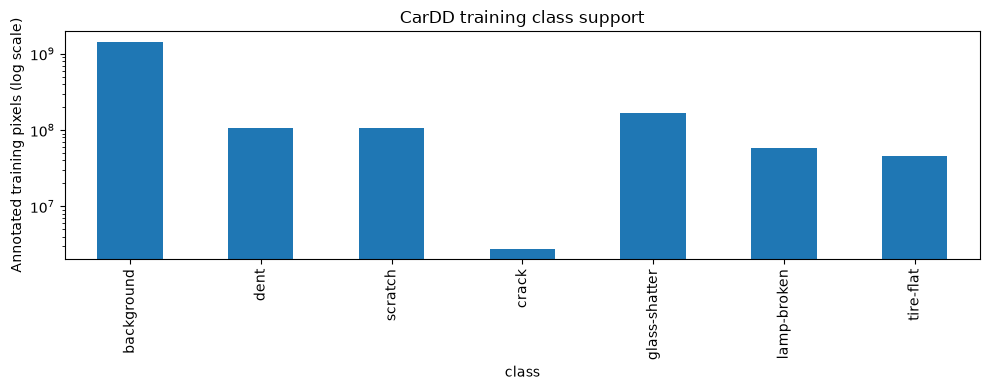

In [6]:
class_names = manifest["class_names"][TASK]
records = [r for r in manifest["records"] if r["task"] == TASK]
train_records = [r for r in records if r["split"] == "train"]
assert class_names[0] == "background" and len(class_names) == 7, class_names
assert train_records, "No training samples: inspect the preparation report."
print("Class IDs:", dict(enumerate(class_names)))
counts = manifest["counts"][TASK]
support = pd.DataFrame({
    "class": class_names,
    "train_pixels": counts["train"]["pixel_counts"],
    "train_images": counts["train"]["images_with_class"],
    "val_images": counts["val"]["images_with_class"],
    "train_instances": [counts["train"]["instances"].get(name, 0) for name in class_names],
})
display(pd.DataFrame({split: {"images": c["images"], "ignored_pixels": c["ignored_pixels"]}
                      for split, c in counts.items()}).T)
display(support)
ax = support.set_index("class")["train_pixels"].plot.bar(figsize=(10, 4), logy=True)
ax.set_ylabel("Annotated training pixels (log scale)")
ax.set_title("CarDD training class support")
plt.tight_layout()
plt.show()


Audit classes: ['tire-flat', 'crack']


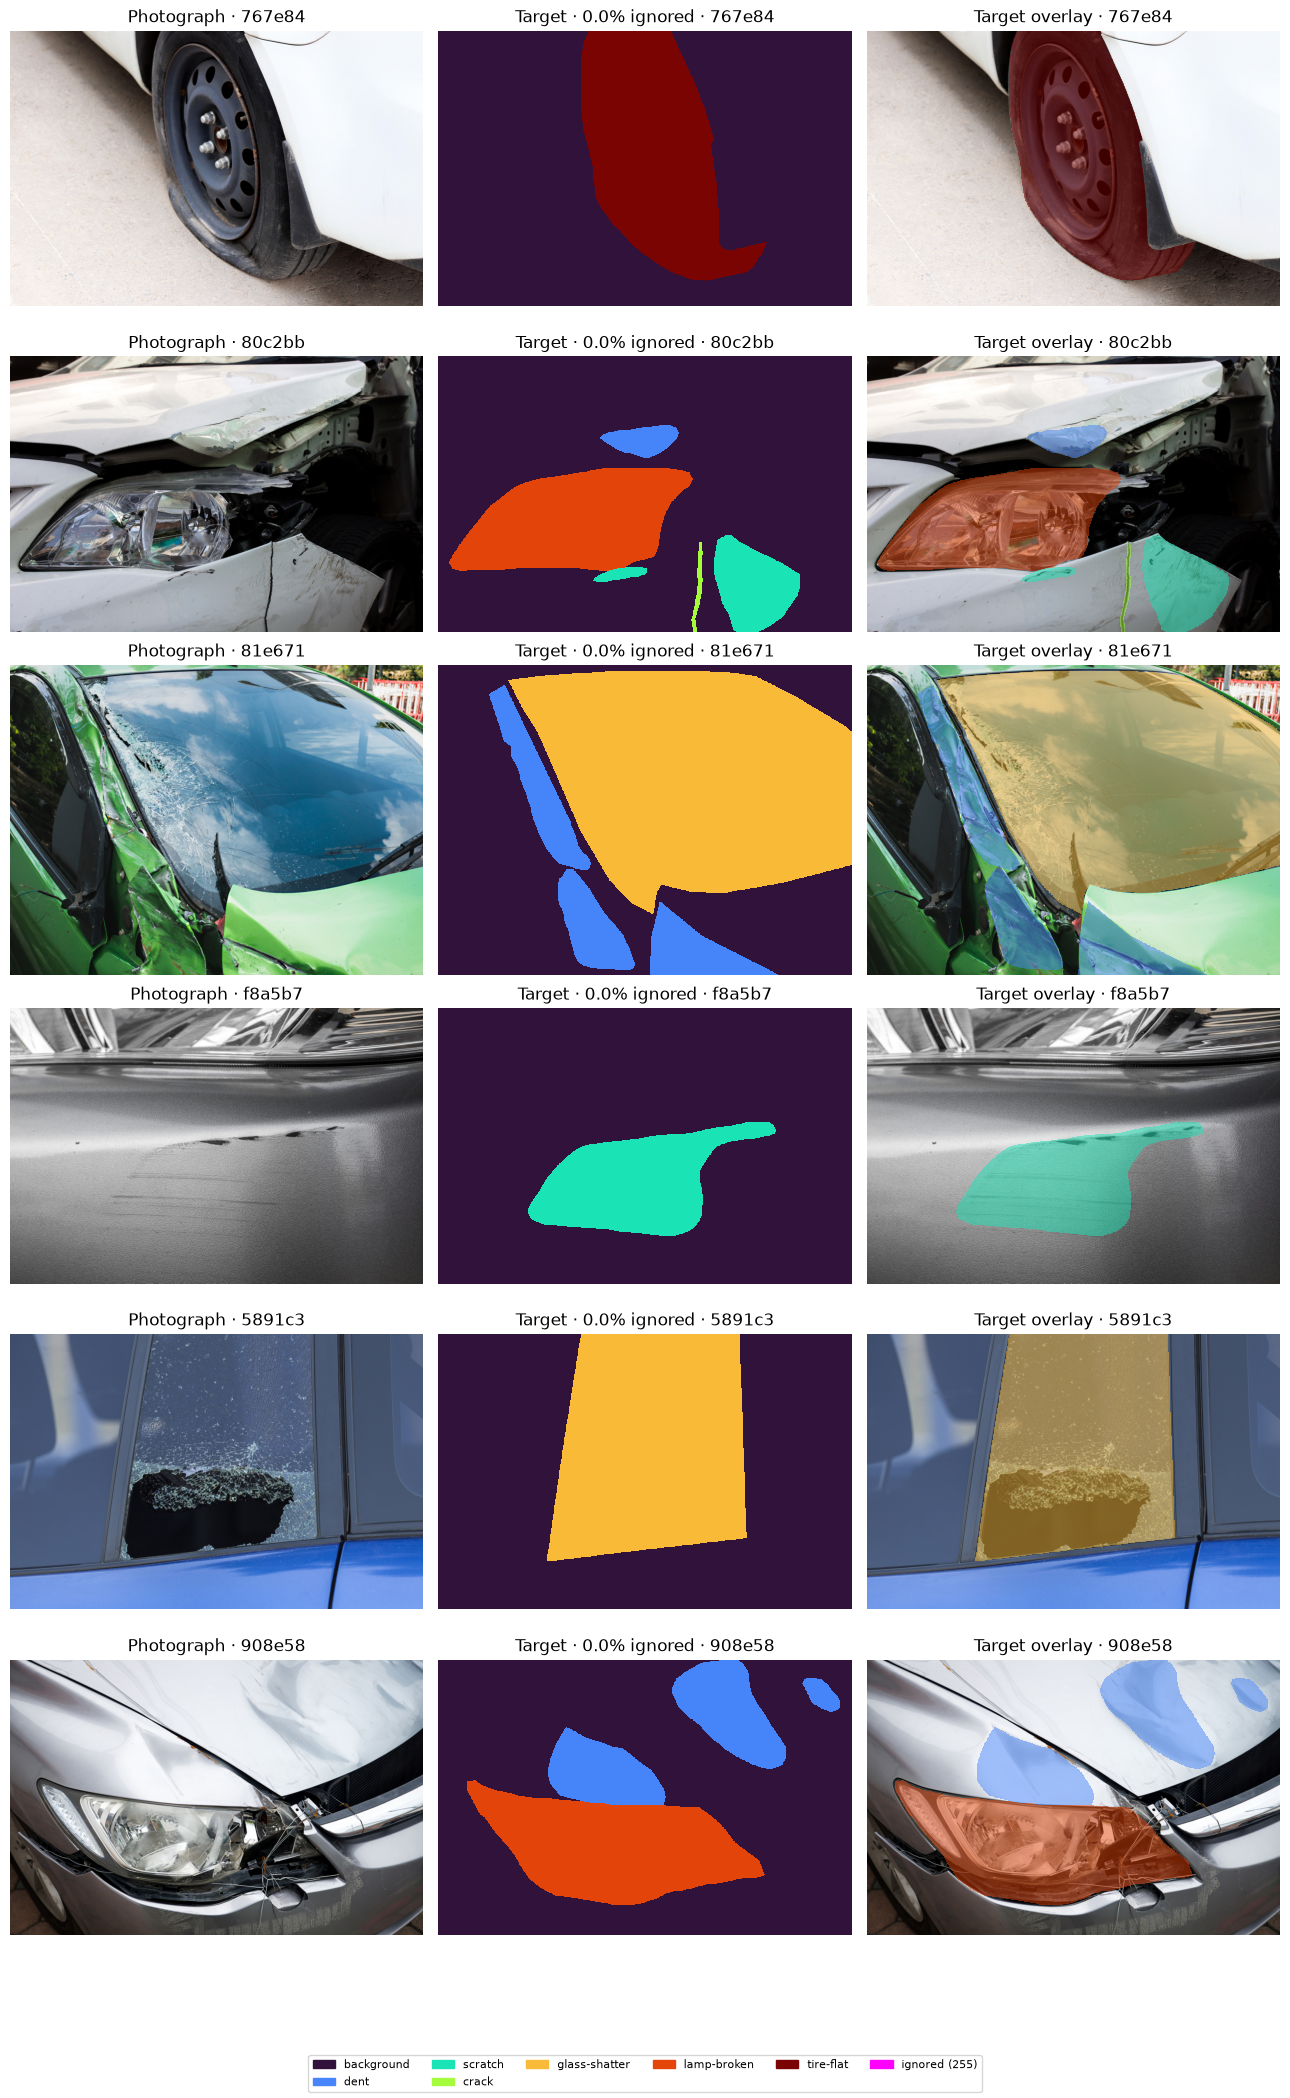

,class,sample_id,source_image,coco_file,coco_image_id
0,tire-flat,cardd-01cb42b5135d6d05c12ba006,/Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...,/Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...,1214
1,tire-flat,cardd-02a05eeba39edaa254ce6483,/Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...,/Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...,1183
2,tire-flat,cardd-0397fc6b06a592c3bae3c952,/Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...,/Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...,1015
3,crack,cardd-0082433a6ed109482e1f2289,/Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...,/Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...,1111
4,crack,cardd-00bd948889f36a785e488854,/Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...,/Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...,1803
5,crack,cardd-00f57dfd586be7f50fe2c393,/Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...,/Users/rodel/Projects/nus/CLAIM-CMEV/data/raw/...,1875


In [7]:
# Inspect prepared labels against the photographs, using TRAINING examples only.
# The two rarest damage classes by training images are shown first.
AUDIT_CLASSES = list(support.iloc[1:].sort_values("train_images")["class"].head(2))
print("Audit classes:", AUDIT_CLASSES)
show_targets(manifest, TASK, split="train", count=6, seed=0, focus_classes=AUDIT_CLASSES)
plt.show()
audit_rows = []
for name in AUDIT_CLASSES:
    idx = class_names.index(name)
    for r in [r for r in train_records if r["pixel_counts"][idx] > 0][:3]:
        audit_rows.append({"class": name, "sample_id": r["sample_id"],
                           "source_image": str(RAW_ROOT / r["source_image"]),
                           "coco_file": str(RAW_ROOT / r["source_annotation"]), "coco_image_id": r["coco_image_id"]})
display(pd.DataFrame(audit_rows))
# A reviewed label correction requires a new prepared version and a recorded reason.


## Model and experiment controls

Every recipe starts from `nvidia/segformer-b2-finetuned-ade-512-512`: an ADE20K-pretrained SegFormer-B2 encoder **and** decoder, with a new seven-class classifier. The decoder's BatchNorm statistics adapt during training. Each recipe trains at 640 pixels with damage-focused crops: 25% whole photographs, 50% crops centred on a damage pixel (preferring `FOCUS_CLASSES`) and 25% random crops. The learning rate warms up for two epochs, then halves whenever validation mIoU stalls.

| Recipe | What it adds |
| --- | --- |
| `focused_640` | The recipe described above |
| `weighted_loss` | Rare-class oversampling, plus cross-entropy weighted by how much rarer each class is than background (square root, capped at 10) |
| `damage_focus` | Stochastic depth 0.2, decoder dropout 0.2, weight decay 0.05 and averaged (EMA) weights at 0.995; **default** |
| `convnext` | UperNet with a ConvNeXt-small backbone instead of SegFormer, as a separate architecture comparison |

CarDD has roughly five times as many images as HITL damage, so each epoch takes about five times longer. The recipes therefore stop after 10 epochs without improvement and run at most 60 epochs. Use `OVERRIDES` to change that. The HITL M2 notebook explains each control in detail.

Set `FOCUS_CLASSES` after looking at the support table above. Thin or small damage, typically scratch and crack, benefits most from focused crops.


In [8]:
FOCUS_CLASSES = ["scratch", "crack"]  # preferred anchors for damage-focused crops
RECIPE = "damage_focus"
BASE_RECIPE = dict(
    architecture="segformer", checkpoint="nvidia/segformer-b2-finetuned-ade-512-512", image_size=640,
    encoder_lr=6e-5, head_lr=6e-4, lr_schedule="plateau", warmup_epochs=2, epochs=60, patience=10,
    freeze_batchnorm=False, crop_mode="damage_aware", scale_range=(1.0, 1.0), rotation_degrees=0,
    saturation=0.10, full_image_probability=0.25, focused_crop_probability=0.50, crop_scale_range=(1.0, 1.5),
    crop_focus_class_ids=tuple(class_names.index(name) for name in FOCUS_CLASSES),
)
RECIPES = {"focused_640": BASE_RECIPE}
RECIPES["weighted_loss"] = {**BASE_RECIPE, "repeat_factor_threshold": 0.20, "max_repeat_factor": 3.0,
                            "class_weighting": "sqrt_inverse", "class_weight_cap": 10.0}
RECIPES["damage_focus"] = {**RECIPES["weighted_loss"], "drop_path_rate": 0.2, "classifier_dropout": 0.2,
                           "weight_decay": 0.05, "ema_decay": 0.995}
RECIPES["convnext"] = {**BASE_RECIPE, "architecture": "hf_semantic",
                       "checkpoint": "openmmlab/upernet-convnext-small", "freeze_batchnorm": True}

# Override any preset here; keep this visible when reporting a run.
OVERRIDES = {}  # e.g. {"epochs": 30} for a shorter first pass, or {"batch_size": 1, "accumulation_steps": 8}
TRAINING_SEED = 20260922
settings = dict(task=TASK, revision=None, pretrained=True, batch_size=2, accumulation_steps=4,
    weight_decay=0.01, freeze_encoder_epochs=0, ce_weight=1.0, dice_weight=0.5, horizontal_flip=0.5,
    brightness=0.15, contrast=0.15, plateau_patience=3, plateau_factor=0.5, plateau_min_lr_ratio=0.01,
    plateau_grace_epochs=3, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225),
    device=DEVICE, amp=True, workers=0, seed=TRAINING_SEED, artifacts_root=str(ROOT / "artifacts"), run_id=None)
settings.update(RECIPES[RECIPE])
settings.update(OVERRIDES)
cfg = TrainingConfig(**settings)
print("Recipe:", RECIPE)
print(json.dumps(asdict(cfg), indent=2))
if cfg.class_weighting != "none":
    loss_weights = class_loss_weights(train_records, len(class_names), cfg.class_weighting, cfg.class_weight_cap)
    display(pd.DataFrame({"class": class_names, "cross_entropy_weight": loss_weights}).round(2))
print("Training images per epoch:", len(train_records))
print("Artifacts:", ROOT / "artifacts/models/damage-cardd")


Recipe: damage_focus
{
  "task": "damage_cardd",
  "architecture": "segformer",
  "checkpoint": "nvidia/segformer-b2-finetuned-ade-512-512",
  "revision": null,
  "pretrained": true,
  "image_size": 640,
  "batch_size": 2,
  "epochs": 60,
  "encoder_lr": 6e-05,
  "head_lr": 0.0006,
  "weight_decay": 0.05,
  "patience": 10,
  "min_delta": 0.0,
  "freeze_encoder_epochs": 0,
  "freeze_batchnorm": false,
  "accumulation_steps": 4,
  "ce_weight": 1.0,
  "dice_weight": 0.5,
  "max_grad_norm": 1.0,
  "lr_schedule": "plateau",
  "warmup_epochs": 2,
  "poly_power": 1.0,
  "horizontal_flip": 0.5,
  "brightness": 0.15,
  "contrast": 0.15,
  "saturation": 0.1,
  "scale_range": [
    1.0,
    1.0
  ],
  "rotation_degrees": 0,
  "crop_mode": "damage_aware",
  "full_image_probability": 0.25,
  "focused_crop_probability": 0.5,
  "crop_scale_range": [
    1.0,
    1.5
  ],
  "crop_focus_class_ids": [
    2,
    3
  ],
  "repeat_factor_threshold": 0.2,
  "max_repeat_factor": 3.0,
  "plateau_patience": 3

,class,cross_entropy_weight
0,background,1.00
1,dent,3.66
2,scratch,3.68
3,crack,10.00
4,glass-shatter,2.91
5,lamp-broken,4.97
6,tire-flat,5.62


Training images per epoch: 2816
Artifacts: /Users/rodel/Projects/nus/CLAIM-CMEV/artifacts/models/damage-cardd


## Preview the actual training crops

These are transformed training examples and their labels, not model predictions. Check that scratches and cracks remain visible at the chosen scale. Validation and test always use the whole photograph; a label-driven crop is never used to choose a validation or test window.


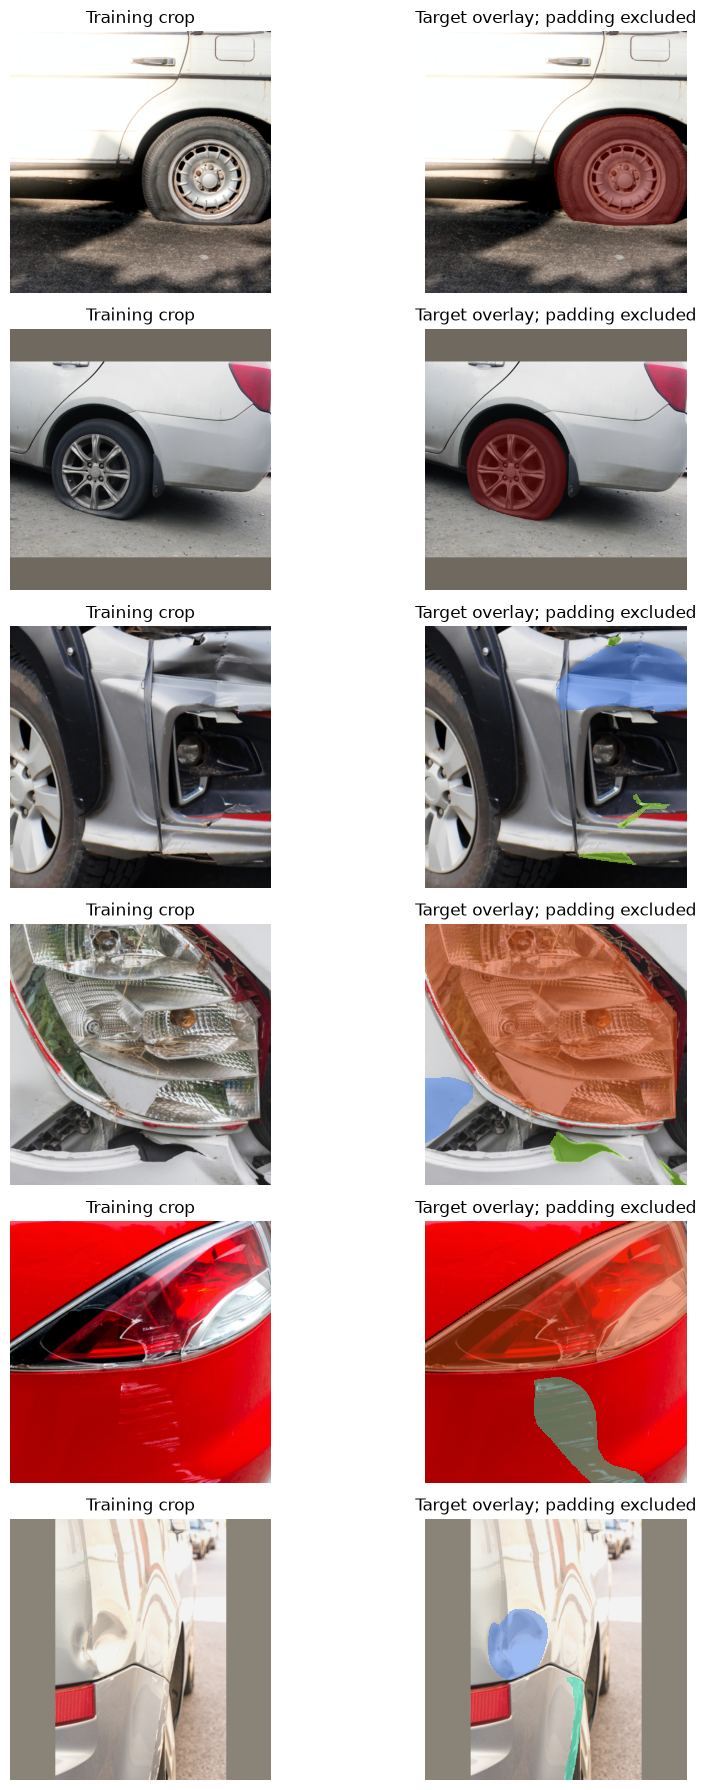

Sampling weights min/max: 1.0 1.6036488074752822 (validation never uses this sampler)


In [9]:
preview_records = []
for name in AUDIT_CLASSES + [n for n in FOCUS_CLASSES if n not in AUDIT_CLASSES]:
    candidates = [r for r in train_records if r["pixel_counts"][class_names.index(name)] > 0]
    preview_records.extend(candidates[:2])
preview_dataset = SegmentationDataset(preview_records, cfg, training=True, num_classes=len(class_names))
state = random.getstate()
random.seed(7)
fig, axes = plt.subplots(len(preview_records), 2, figsize=(10, 3 * len(preview_records)), squeeze=False)
try:
    for row in range(len(preview_records)):
        item = preview_dataset[row]
        rgb = item["pixel_values"].numpy().transpose(1, 2, 0) * np.asarray(cfg.std) + np.asarray(cfg.mean)
        labels = item["labels"].numpy()
        for axis in axes[row]:
            axis.imshow(rgb.clip(0, 1))
            axis.axis("off")
        axes[row, 1].imshow(np.ma.masked_where((labels == 0) | (labels == 255), labels),
                            cmap="turbo", vmin=0, vmax=len(class_names) - 1, alpha=0.5, interpolation="nearest")
        axes[row, 0].set_title("Training crop")
        axes[row, 1].set_title("Target overlay; padding excluded")
finally:
    random.setstate(state)
plt.tight_layout()
plt.show()
if cfg.repeat_factor_threshold:
    weights = repeat_sampling_weights(train_records, len(class_names), cfg.repeat_factor_threshold, cfg.max_repeat_factor)
    print("Sampling weights min/max:", min(weights), max(weights), "(validation never uses this sampler)")


## Inspect the model architecture

The next cell builds the configured model once, on the CPU, so you can see it before training. The table lists modules down to `SUMMARY_DEPTH` levels with their parameter counts, and marks whether it belongs to the pretrained encoder or the decoder/head. A test pass with a blank image confirms the model returns one score per class for every input pixel. Set `PRINT_FULL_ARCHITECTURE = True` to print the complete PyTorch module tree (several hundred lines for SegFormer).

Building the model loads the pretrained weights, which downloads them on first use. This preview copy is discarded; the training cell builds its own.


In [10]:
# Build the configured model once on the CPU to inspect it. Training builds its own copy.
PRINT_FULL_ARCHITECTURE = False  # True prints every layer
SUMMARY_DEPTH = 4  # 4 shows SegFormer's four encoder stages; lower it for ResNet backbones
preview_model = build_model(cfg, class_names).eval()
display(model_summary(preview_model, depth=SUMMARY_DEPTH))
encoder_total = sum(p.numel() for p in preview_model.encoder_parameters())
head_total = sum(p.numel() for p in preview_model.head_parameters())
print(f"Encoder parameters: {encoder_total:,} | head/decoder: {head_total:,} | total: {encoder_total + head_total:,}")
with torch.inference_mode():
    blank = torch.zeros(1, 3, cfg.image_size, cfg.image_size)
    print("Input", tuple(blank.shape), "-> logits", tuple(preview_model(blank).shape),
          f"= one score per class ({len(class_names)}) per pixel")
if PRINT_FULL_ARCHITECTURE:
    print(preview_model.network)
del preview_model, blank


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b2-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.weight: found shape torch.Size([150, 768, 1, 1]) in the checkpoint and torch.Size([7, 768, 1, 1]) in the model instantiated
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([7]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


,module,type,level,parameters,part
0,segformer,SegformerModel,1,24196288,encoder
1,segformer.encoder,SegformerEncoder,2,24196288,encoder
2,segformer.encoder.patch_embeddings,ModuleList,3,1929408,encoder
3,segformer.encoder.patch_embeddings.0,SegformerOverlapPatchEmbeddings,4,9600,encoder
4,segformer.encoder.patch_embeddings.1,SegformerOverlapPatchEmbeddings,4,74112,encoder
5,segformer.encoder.patch_embeddings.2,SegformerOverlapPatchEmbeddings,4,369600,encoder
6,segformer.encoder.patch_embeddings.3,SegformerOverlapPatchEmbeddings,4,1476096,encoder
7,segformer.encoder.block,ModuleList,3,22264832,encoder
8,segformer.encoder.block.0,ModuleList,4,944640,encoder
9,segformer.encoder.block.1,ModuleList,4,1863680,encoder


Encoder parameters: 24,196,288 | head/decoder: 3,155,719 | total: 27,352,007
Input (1, 3, 640, 640) -> logits (1, 7, 640, 640) = one score per class (7) per pixel


## Run training manually

Run the next cell once the data audit and configuration are ready. It loads the pretrained checkpoint (a download on first use), creates a unique run under `artifacts/models/damage-cardd/`, and records the configuration, class mapping, data and split fingerprints, environment, checkpoints and validation history. Each epoch prints validation foreground mIoU and any-damage IoU, recall and precision. `best.pt` is selected by validation foreground mIoU; `last.pt` is kept too.

Expect each epoch to take roughly five times as long as a HITL damage epoch at the same size. Interrupting the kernel is safe: `best.pt` keeps the best epoch so far, and the run is marked `interrupted`. Each execution starts a new run; exact resume is not implemented.


In [11]:
run = train(manifest, cfg)
RUN_DIR = Path(run["run_dir"])
EVALUATION_DIR = Path(run["evaluation_dir"])
print("Model and training artifacts:", RUN_DIR)
print("Evaluation artifacts:", EVALUATION_DIR)


Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b2-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.weight: found shape torch.Size([150, 768, 1, 1]) in the checkpoint and torch.Size([7, 768, 1, 1]) in the model instantiated
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([7]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


epoch 1/60: train loss 1.7750, val loss 0.9446, val foreground mIoU 0.4574, any-damage IoU 0.6197 (recall 0.875, precision 0.680)
epoch 2/60: train loss 0.9981, val loss 0.7904, val foreground mIoU 0.5079, any-damage IoU 0.6397 (recall 0.940, precision 0.667)
epoch 3/60: train loss 0.8415, val loss 0.7084, val foreground mIoU 0.5814, any-damage IoU 0.6833 (recall 0.942, precision 0.713)
epoch 4/60: train loss 0.7802, val loss 0.6750, val foreground mIoU 0.6012, any-damage IoU 0.7017 (recall 0.943, precision 0.733)
epoch 5/60: train loss 0.7418, val loss 0.6615, val foreground mIoU 0.6157, any-damage IoU 0.7121 (recall 0.942, precision 0.745)
epoch 6/60: train loss 0.6968, val loss 0.6457, val foreground mIoU 0.6359, any-damage IoU 0.7261 (recall 0.944, precision 0.759)
epoch 7/60: train loss 0.6966, val loss 0.6486, val foreground mIoU 0.6293, any-damage IoU 0.7117 (recall 0.954, precision 0.737)
epoch 8/60: train loss 0.6495, val loss 0.6359, val foreground mIoU 0.6475, any-damage IoU

## Validation metrics and performance plots

Validation evaluation reloads the **best** checkpoint, so it also checks that the saved weights load. Report every class with its pixel support, IoU, Dice, precision and recall; classes with no support stay explicit instead of being shown as perfect. Foreground mIoU excludes background. `binary_foreground` collapses all six classes into damage versus background: it separates "found the damage" from "named it correctly". It does not measure damage-to-part assignment.

The specification target (0.45) applies to the **test** split. Validation scores guide choices; they are not the acceptance result.


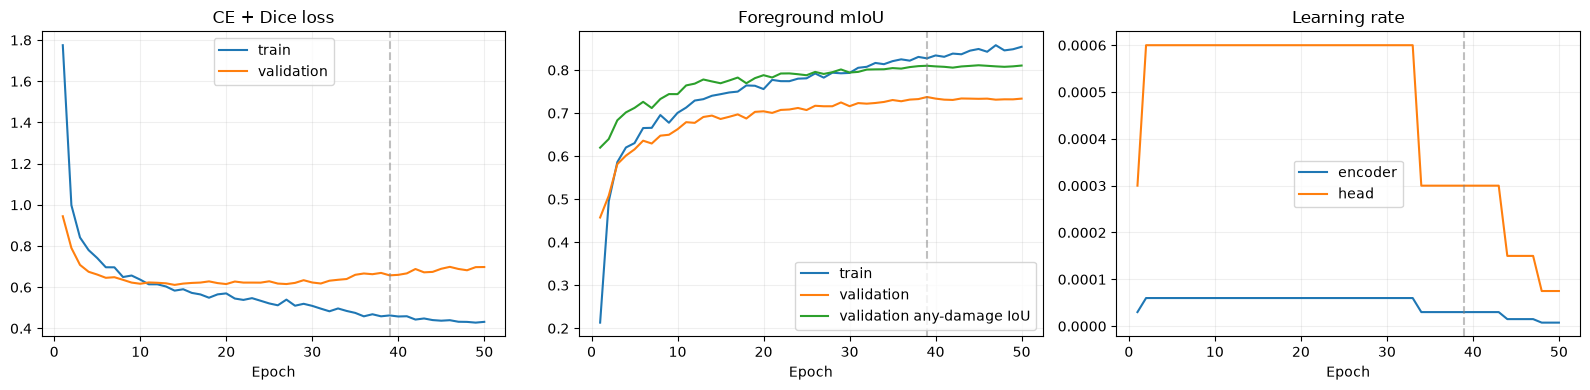

{'miou_foreground': 0.7373947145962992,
 'dice_foreground': 0.8368379895435422,
 'precision_foreground': 0.8084421636290178,
 'recall_foreground': 0.868361706599105,
 'pixel_accuracy': 0.9393725668962879,
 'valid_pixels': 227528320,
 'macro_class_count': 6,
 'macro_policy': 'background excluded; zero-union classes undefined/excluded; false-positive-only classes included',
 'binary_foreground': {'iou': 0.8099655793024311,
  'precision': 0.8688682254184767,
  'recall': 0.9227664294409863,
  'dice': 0.8950066106943265,
  'true_positive': 53688664,
  'false_positive': 8102828,
  'false_negative': 4493626,
  'iou_reason': None,
  'policy': 'Collapse multiclass argmax IDs > 0; ignore 255 truth; no tuned threshold'},
 'loss': 0.6575903632758576,
 'image_count': 810,
 'elapsed_seconds': 51.02105166600086,
 'background_offset': 0.0,
 'images_per_second': 15.875799764036687,
 'timing_scope': 'full evaluation including loading, loss and CPU confusion',
 'split': 'val',
 'epoch': 39,
 'run_id': 'd

,class_id,class_name,iou,dice,precision,recall,support_pixels,predicted_pixels,iou_reason
0,0,background,0.927540,0.962408,0.972887,0.952152,169346030,165736828,None
1,1,dent,0.613450,0.760420,0.733374,0.789537,12272230,13212053,None
2,2,scratch,0.651513,0.788989,0.743808,0.840013,13072153,14762920,None
3,3,crack,0.472956,0.642186,0.598760,0.692404,375844,434625,None
4,4,glass-shatter,0.964243,0.981796,0.977948,0.985675,21372813,21541677,None
5,5,lamp-broken,0.790465,0.882972,0.844294,0.925363,6611008,7245801,None
6,6,tire-flat,0.931742,0.964665,0.952469,0.977178,4478242,4594416,None


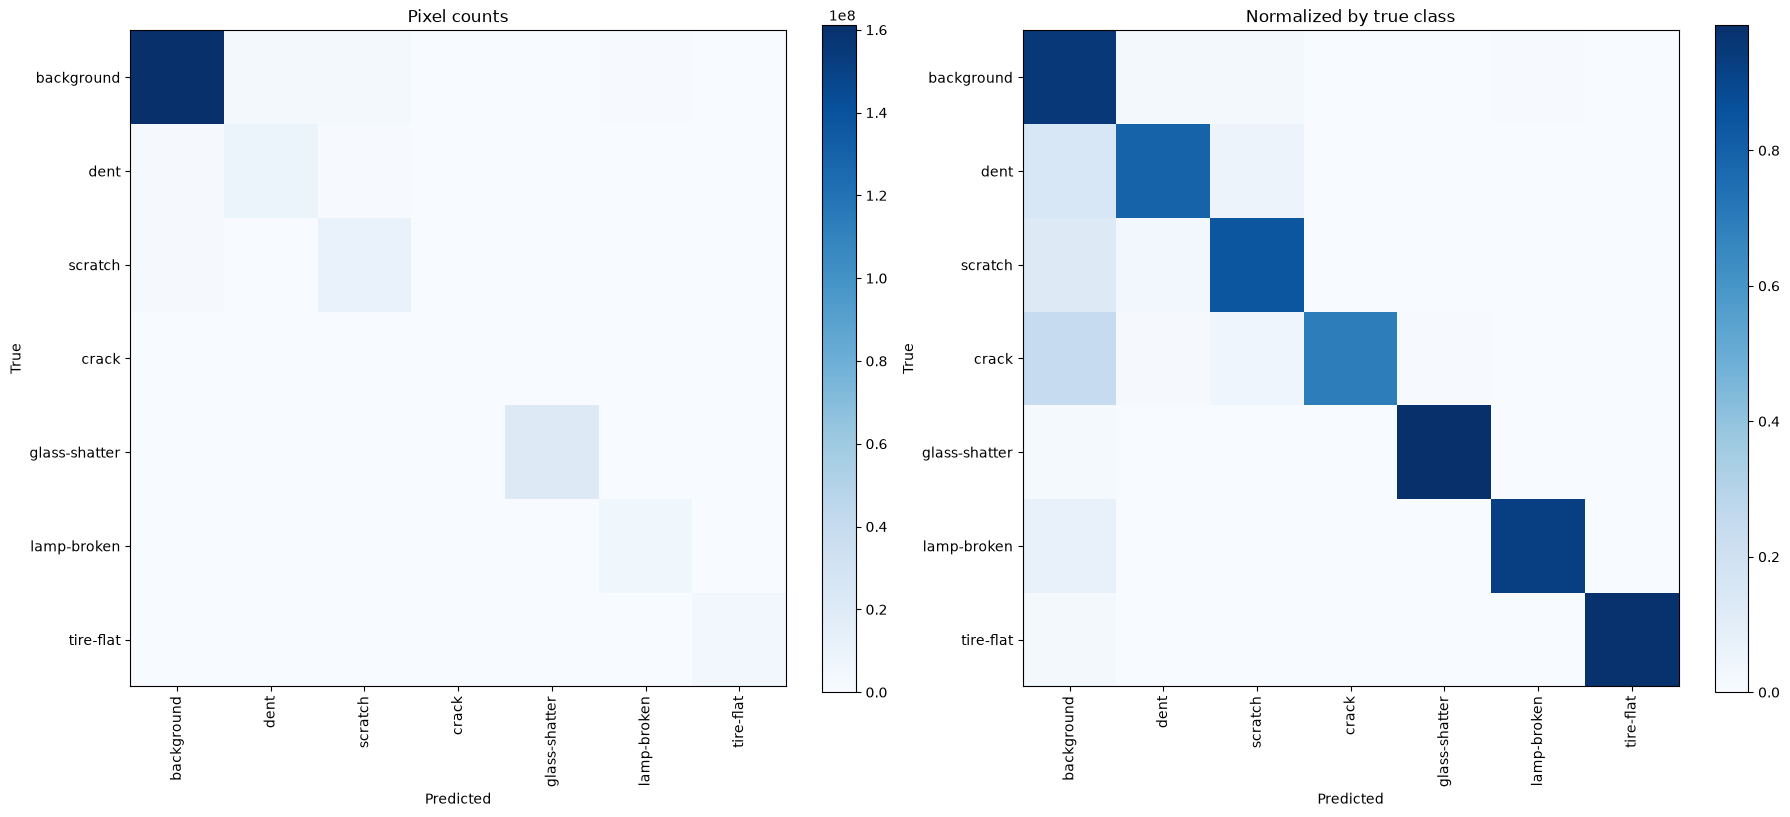

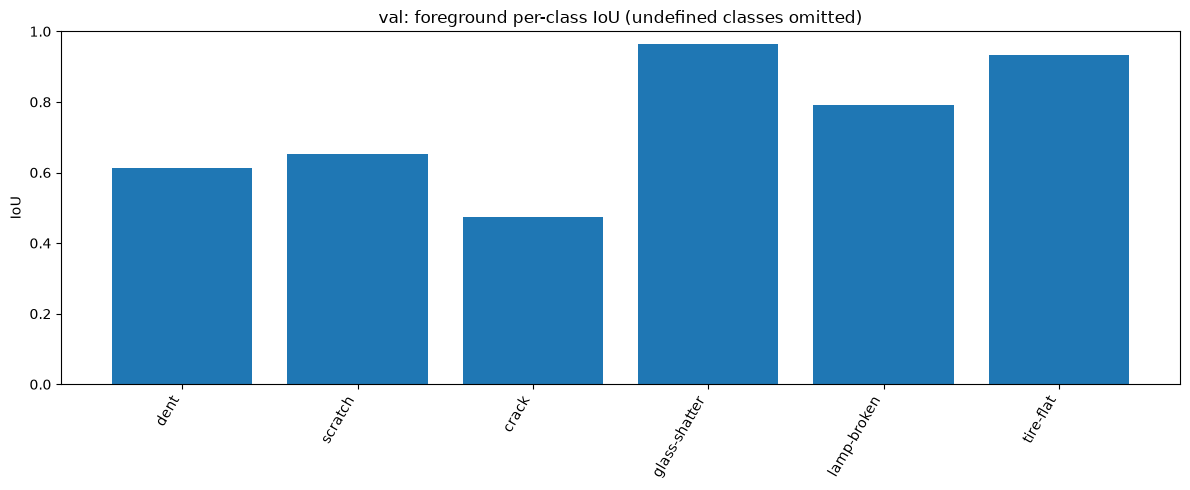

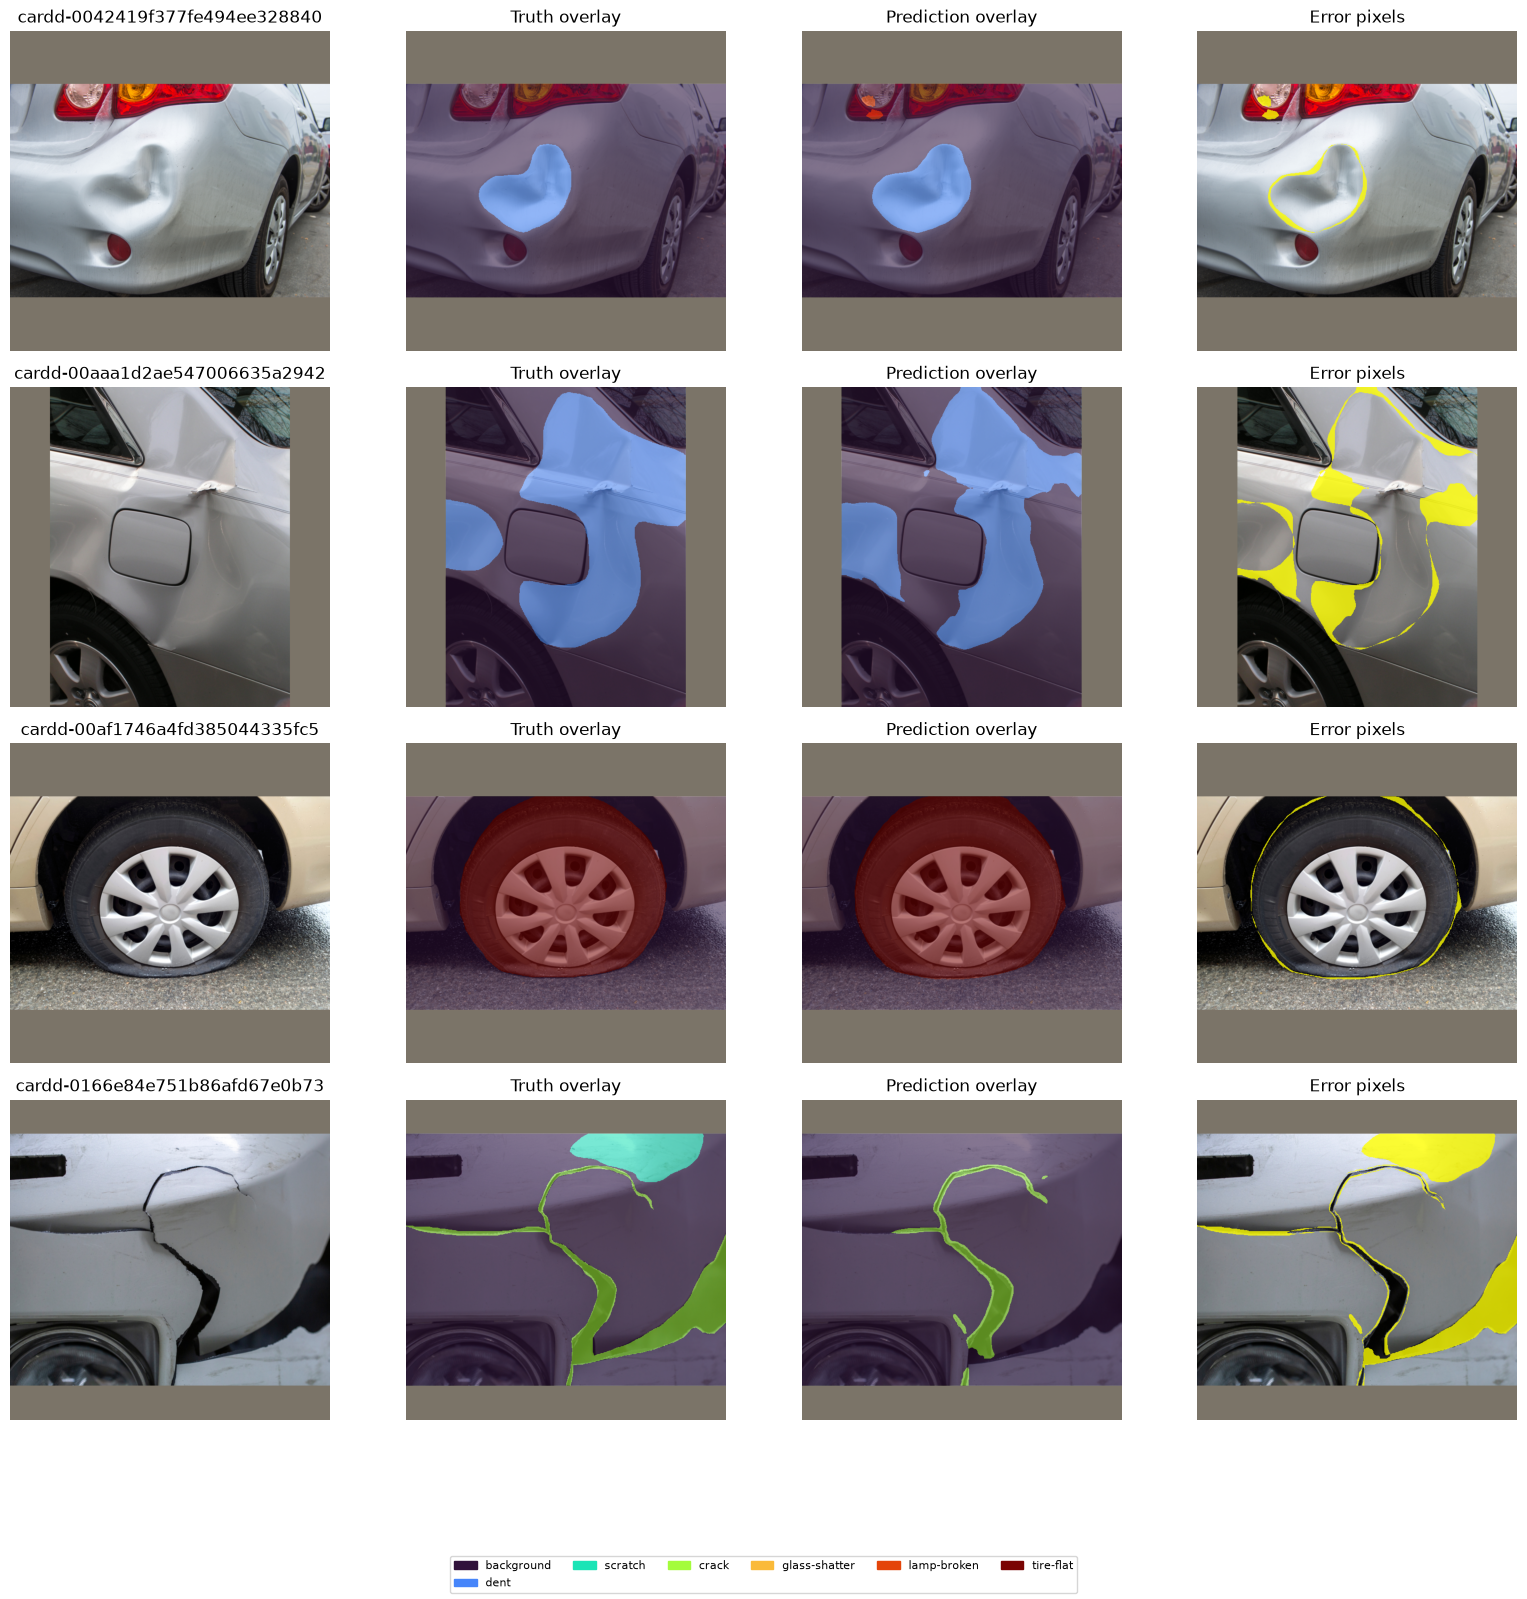

In [12]:
plot_history(RUN_DIR)
plt.show()
validation_report = evaluate_run(RUN_DIR, manifest, split="val", device=DEVICE)
display({k: v for k, v in validation_report.items()
         if k not in {"per_class", "confusion_matrix"}})
display(pd.DataFrame(validation_report["per_class"]))
plot_confusion(RUN_DIR, split="val")
plt.show()
show_predictions(RUN_DIR, manifest, split="val", count=4, device=DEVICE)
plt.show()


## Compare runs at a common validation resolution

Re-evaluate **every** compared checkpoint at the same whole-image size, here 640, before comparing. Reports are saved as `val_size640_*`, beside each run's original metrics. The comparison refuses runs on different prepared data, splits or class lists, so HITL runs cannot be mixed in.


In [13]:
RUNS_TO_COMPARE = [str(RUN_DIR)]
# Add other CarDD runs deliberately, e.g.:
# RUNS_TO_COMPARE += [str(ROOT / "artifacts/models/damage-cardd/<run-id>")]
COMMON_EVAL_SIZE = 640  # Same evaluation grid for EVERY compared checkpoint.
for directory in RUNS_TO_COMPARE:
    evaluate_run(directory, manifest, split="val", device=DEVICE, image_size=COMMON_EVAL_SIZE)
comparison = compare_runs(RUNS_TO_COMPARE, evaluation_image_size=COMMON_EVAL_SIZE)
display(comparison)
SAVE_COMPARISON = False
if SAVE_COMPARISON:
    comparison.to_csv(EVALUATION_DIR / "manual_validation_comparison.csv", index=False)


,run_id,architecture,checkpoint,seed,best_epoch,val_miou,val_dice,binary_iou,training_image_size,evaluation_image_size,parameters,device
0,damage_cardd-segformer-20261002T043059Z-7981a76f,segformer,nvidia/segformer-b2-finetuned-ade-512-512,20260922,39,0.737395,0.836838,0.809966,640,640,27352007,mps


## Tune the background offset on validation (optional)

A pixel is labelled damage only when some damage score beats the background score. Lowering the background score by an **offset** makes the model call damage more readily: recall rises and precision falls. A negative offset does the opposite. If validation precision is well above recall, a positive offset may help.

The next cell scores a range of offsets on the **validation** split in one inference pass and keeps the one with the best foreground mIoU. Set `OFFSET_OBJECTIVE = "binary_iou"` to optimise damage-vs-background instead; ties prefer the smaller change. The table, plot and choice are saved as `val_size<N>_background_offset.json`, and tuned reports as `val_size<N>_bg<offset>_*` beside the untuned ones. The final-test cell reuses `BACKGROUND_OFFSET` unchanged. Never re-tune it on test.


,background_offset,miou_foreground,binary_iou,binary_recall,binary_precision,iou_dent,iou_scratch,iou_crack,iou_glass-shatter,iou_lamp-broken,iou_tire-flat
0,-1.00,0.7436,0.8168,0.8926,0.9059,0.6182,0.6568,0.4809,0.9644,0.8013,0.9400
1,-0.75,0.7432,0.8165,0.9010,0.8969,0.6188,0.6578,0.4798,0.9646,0.7995,0.9386
2,-0.50,0.7419,0.8152,0.9088,0.8878,0.6184,0.6570,0.4781,0.9647,0.7971,0.9364
3,-0.25,0.7401,0.8130,0.9161,0.8784,0.6166,0.6549,0.4761,0.9646,0.7940,0.9342
4,0.00,0.7374,0.8100,0.9228,0.8689,0.6134,0.6515,0.4730,0.9642,0.7905,0.9317
5,0.25,0.7341,0.8062,0.9290,0.8592,0.6095,0.6469,0.4688,0.9637,0.7871,0.9289
6,0.50,0.7302,0.8017,0.9346,0.8493,0.6047,0.6411,0.4636,0.9630,0.7835,0.9255
7,0.75,0.7258,0.7965,0.9398,0.8393,0.5992,0.6343,0.4579,0.9619,0.7799,0.9219
8,1.00,0.7209,0.7906,0.9444,0.8292,0.5929,0.6265,0.4514,0.9606,0.7758,0.9182
9,1.25,0.7156,0.7842,0.9485,0.8190,0.5863,0.6180,0.4448,0.9590,0.7714,0.9142


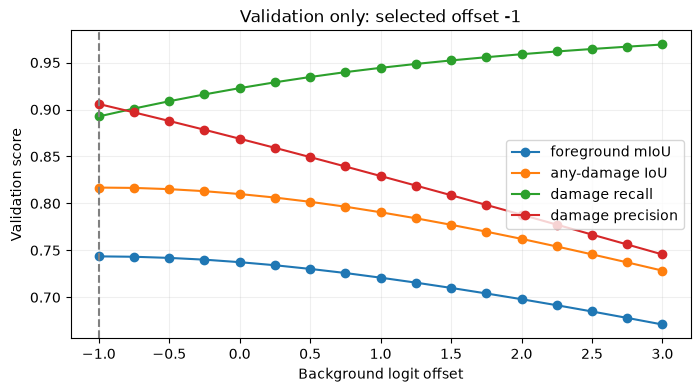

,class_id,class_name,iou,dice,precision,recall,support_pixels,predicted_pixels,iou_reason
0,0,background,0.933683,0.965704,0.963289,0.968132,169346030,170197464,None
1,1,dent,0.618173,0.764038,0.791377,0.738525,12272230,11452629,None
2,2,scratch,0.656780,0.792839,0.797273,0.788454,13072153,12927563,None
3,3,crack,0.480879,0.649451,0.656082,0.642953,375844,368323,None
4,4,glass-shatter,0.964377,0.981865,0.985847,0.977916,21372813,21200867,None
5,5,lamp-broken,0.801284,0.889681,0.871215,0.908946,6611008,6897317,None
6,6,tire-flat,0.939959,0.969050,0.968411,0.969690,4478242,4484157,None


BACKGROUND_OFFSET = -1.0


In [14]:
TUNE_BACKGROUND_OFFSET = True
OFFSET_EVAL_SIZE = 640  # Keep equal to COMMON_EVAL_SIZE and FINAL_EVAL_SIZE.
OFFSET_OBJECTIVE = "miou_foreground"  # or "binary_iou"
BACKGROUND_OFFSET = 0.0
if TUNE_BACKGROUND_OFFSET:
    BACKGROUND_OFFSET, offset_table = tune_background_offset(
        RUN_DIR, manifest, device=DEVICE, image_size=OFFSET_EVAL_SIZE, objective=OFFSET_OBJECTIVE)
    display(offset_table.round(4))
    fig, ax = plt.subplots(figsize=(8, 4))
    for column, label in (("miou_foreground", "foreground mIoU"), ("binary_iou", "any-damage IoU"),
                          ("binary_recall", "damage recall"), ("binary_precision", "damage precision")):
        ax.plot(offset_table["background_offset"], offset_table[column], marker="o", label=label)
    ax.axvline(BACKGROUND_OFFSET, color="grey", linestyle="--")
    ax.set(xlabel="Background logit offset", ylabel="Validation score",
           title=f"Validation only: selected offset {BACKGROUND_OFFSET:g}")
    ax.legend()
    ax.grid(alpha=0.2)
    plt.show()
    tuned_report = evaluate_run(RUN_DIR, manifest, split="val", device=DEVICE,
                                image_size=OFFSET_EVAL_SIZE, background_offset=BACKGROUND_OFFSET)
    display(pd.DataFrame(tuned_report["per_class"]))
print("BACKGROUND_OFFSET =", BACKGROUND_OFFSET)


## Reload an existing checkpoint without another training run

After a kernel restart, rerun the imports and preparation/configuration cells, set `RELOAD_RUN_DIR` to a saved run below, then run the validation plotting/evaluation cell. Evaluation rebuilds the architecture from its persisted configuration and loads `best.pt`; it checks task/data compatibility. Move the corresponding prepared dataset and manifest with the run when using another machine, and preserve recorded content identities. This is model reload for inference/evaluation, not optimizer resume.


In [ ]:
RELOAD_RUN_DIR = None  # e.g. ROOT / "artifacts/models/damage-cardd/<saved-run-id>"
if RELOAD_RUN_DIR is not None:
    RUN_DIR = Path(RELOAD_RUN_DIR).expanduser().resolve()
    if not (RUN_DIR / "best.pt").is_file():
        raise FileNotFoundError(f"No saved best checkpoint in {RUN_DIR}")
    EVALUATION_DIR = ROOT / "artifacts/evaluation" / RUN_DIR.name
    print("Reload selected:", RUN_DIR)
    reloaded_validation_report = evaluate_run(RUN_DIR, manifest, split="val", device=DEVICE)
    display(reloaded_validation_report)


## Final held-out evaluation — explicit opt-in

Leave `FINAL_EVAL=False` throughout development. Set it to `True` only after selecting and freezing the final run using validation, with no pending split/taxonomy edits. Evaluation exports metrics, the confusion matrix and qualitative results under `artifacts/evaluation/<run_id>/`. Test results must not become a feedback loop for architecture or threshold selection. A later design change requires a new declared evaluation protocol, not repeated claims of untouched test performance.


If selection used common-resolution metrics, use the same `FINAL_EVAL_SIZE` below. Those reports and plots are written separately from the run's original-resolution metrics. Inspect that choice on validation first; changing only the final-test procedure invalidates the comparison. The final test also reuses the validation-selected `BACKGROUND_OFFSET` unchanged, or 0 if the tuning cell was skipped.


In [ ]:
FINAL_EVAL = False
FINAL_EVAL_SIZE = 640  # Match the frozen common validation protocol.
FINAL_BACKGROUND_OFFSET = globals().get("BACKGROUND_OFFSET", 0.0)  # Chosen on validation; never tuned on test.
if FINAL_EVAL:
    print("Background offset (from validation):", FINAL_BACKGROUND_OFFSET)
    final_report = evaluate_run(RUN_DIR, manifest, split="test", device=DEVICE, image_size=FINAL_EVAL_SIZE,
                                background_offset=FINAL_BACKGROUND_OFFSET)
    display({k: v for k, v in final_report.items() if k not in {"per_class", "confusion_matrix"}})
    display(pd.DataFrame(final_report["per_class"]))
    plot_confusion(RUN_DIR, split="test", image_size=FINAL_EVAL_SIZE, background_offset=FINAL_BACKGROUND_OFFSET)
    plt.show()
    show_predictions(RUN_DIR, manifest, split="test", count=4, device=DEVICE, image_size=FINAL_EVAL_SIZE,
                     background_offset=FINAL_BACKGROUND_OFFSET)
    plt.show()
else:
    print("Final test remains unused. Continue model selection with validation only.")


## Interpretation, artifacts and next steps

The M2 specification target is **foreground mIoU of at least 0.45 on the held-out CarDD test split**, with per-class IoU and support for all six classes, none omitted after seeing errors. Report the test result once, with the frozen recipe, checkpoint, evaluation size and background offset. A shortfall is reported against the target, not hidden.

- **Not comparable with HITL.** HITL damage has eight different classes and a different split; do not put CarDD and HITL scores in one table as if they measured the same thing.
- **Damage-to-part assignment is separate.** The application overlays M2's damage mask on M1's part mask from the same photograph. Many CarDD photographs are close-ups, where M1 may not identify the part; the system then withholds a decision rather than guessing. Check assignment on photographs that resemble real claim photos.
- **Background is not proof of no damage.** CarDD annotates six damage types only.

Model files go under `artifacts/models/damage-cardd/<run_id>/` and reports under `artifacts/evaluation/<run_id>/`. Keep the prepared-data manifest with any checkpoint you copy elsewhere. A trained checkpoint is a candidate only; serving it requires the separate adapter and registry acceptance described in the M2 specification.
